In [125]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns


In [126]:
data_set=pd.read_csv('/content/sample_data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [127]:
data_set

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


**Data Processing**


In [128]:
data_set.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [129]:
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [130]:
data_set.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [131]:
num_columns=data_set.select_dtypes(include=np.number).columns
catogorical_cols=data_set.select_dtypes(include=np.object_).columns
num_columns
catogorical_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

In [132]:
#decrbing the  numerical
data_set.describe(include='int')

,SeniorCitizen,tenure
count,7043.000000,7043.000000
mean,0.162147,32.371149
std,0.368612,24.559481
min,0.000000,0.000000
25%,0.000000,9.000000
50%,0.000000,29.000000
75%,0.000000,55.000000
max,1.000000,72.000000


In [133]:
#decrbing the  catogorical
data_set.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [134]:
data_set.drop(columns=["customerID"],inplace=True)

In [135]:
df=pd.read_csv('/content/sample_data/WA_Fn-UseC_-Telco-Customer-Churn.csv')


In [136]:
from sklearn.preprocessing import LabelEncoder
lc=LabelEncoder()

# Convert 'TotalCharges' to numeric, coercing errors to NaN
data_set['TotalCharges'] = pd.to_numeric(data_set['TotalCharges'], errors='coerce')

# Fill NaN values in 'TotalCharges' with 0. You might choose a different imputation strategy.
data_set['TotalCharges'].fillna(0, inplace=True)

# Re-identify categorical columns after preprocessing to ensure accuracy.
# This list should now exclude 'customerID' (which was dropped) and 'TotalCharges' (which is now numeric).
categorical_cols_for_encoding = data_set.select_dtypes(include='object').columns

for col in categorical_cols_for_encoding:
  data_set[col] = lc.fit_transform(data_set[col])
data_set

/tmp/ipykernel_3681/3422290985.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_set['TotalCharges'].fillna(0, inplace=True)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50,0
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90,0
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45,0
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60,1


# New Section
EDA


In [137]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


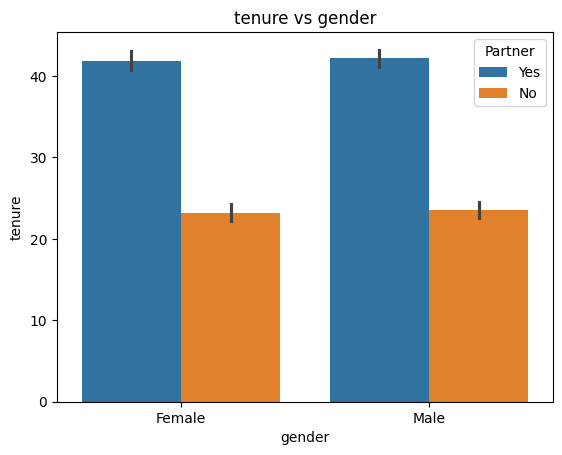

In [138]:
sns.barplot(x="gender",y="tenure",data=df,hue="Partner")
plt.title("tenure vs gender")
plt.show()

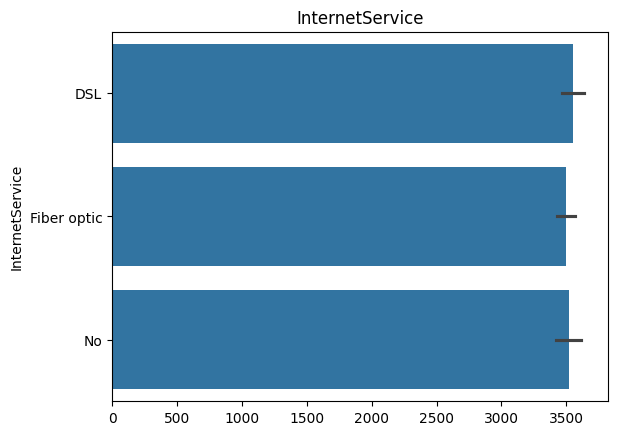

In [139]:
sns.barplot(data=df["InternetService"])
plt.title("InternetService")

plt.show()

<Axes: xlabel='gender', ylabel='count'>

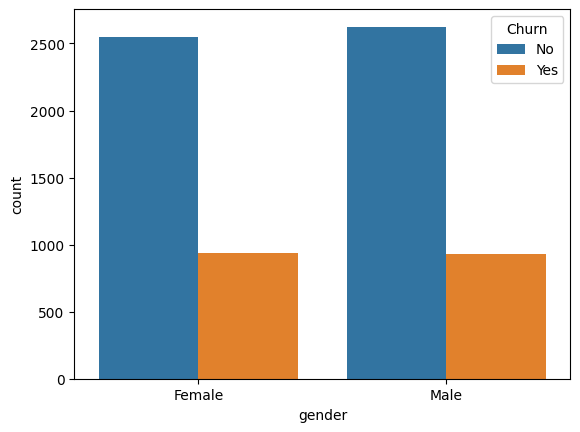

In [140]:
sns.countplot(x="gender",hue='Churn',data=df)

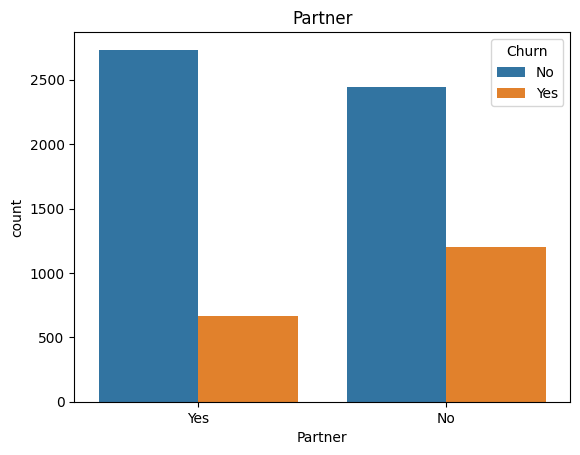

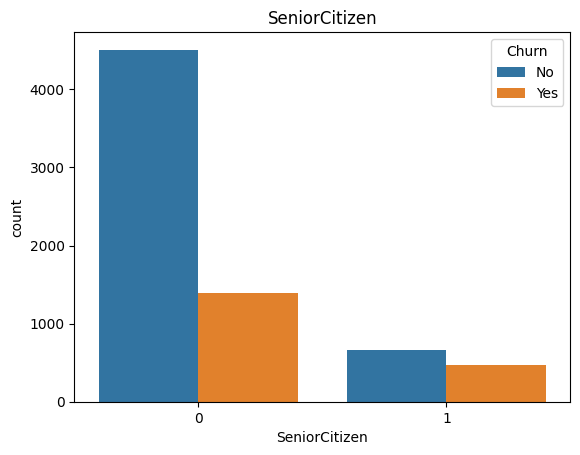

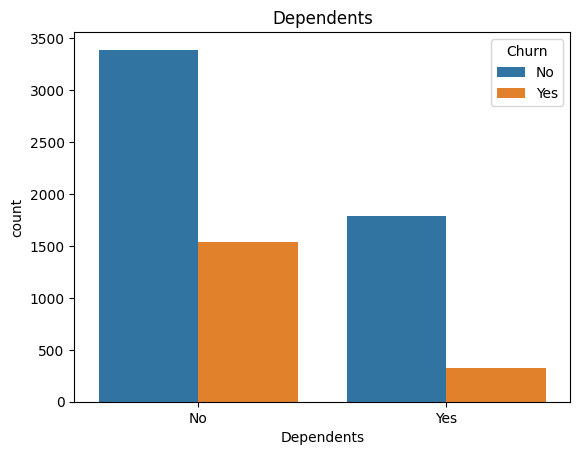

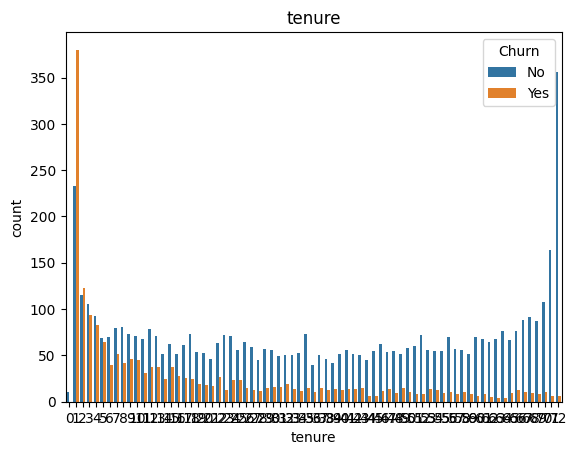

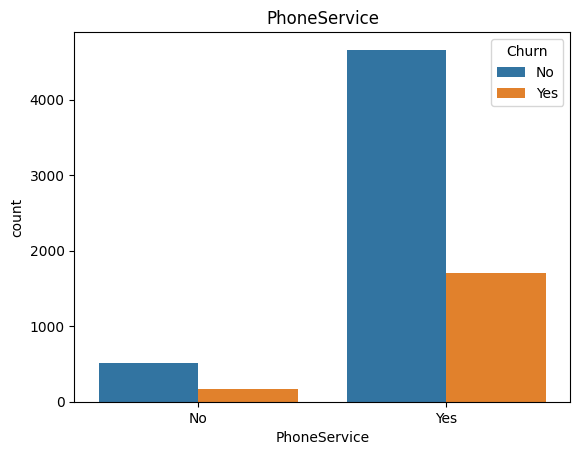

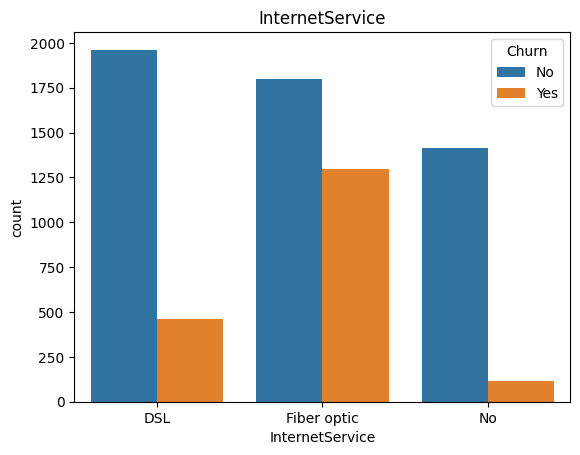

In [141]:
sns.countplot(data=df,x='Partner',hue='Churn')
plt.title("Partner")
plt.show()
sns.countplot(data=df,x='SeniorCitizen',hue='Churn')
plt.title("SeniorCitizen")
plt.show()
sns.countplot(data=df,x='Dependents',hue='Churn')
plt.title("Dependents")
plt.show()
sns.countplot(data=df,x='tenure',hue='Churn')
plt.title("tenure")
plt.show()
sns.countplot(data=df,x='PhoneService',hue='Churn')
plt.title("PhoneService")
plt.show()
sns.countplot(data=df,x='InternetService',hue='Churn')
plt.title("InternetService")
plt.show()

In [142]:
data_set.corr()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
gender,1.000000,-0.001874,-0.001808,0.010517,0.005106,-0.006488,-0.006739,-0.000863,-0.015017,-0.012057,0.000549,-0.006825,-0.006421,-0.008743,0.000126,-0.011754,0.017352,-0.014569,-0.000080,-0.008612
SeniorCitizen,-0.001874,1.000000,0.016479,-0.211185,0.016567,0.008576,0.146185,-0.032310,-0.128221,-0.013632,-0.021398,-0.151268,0.030776,0.047266,-0.142554,0.156530,-0.038551,0.220173,0.103006,0.150889
Partner,-0.001808,0.016479,1.000000,0.452676,0.379697,0.017706,0.142410,0.000891,0.150828,0.153130,0.166330,0.126733,0.137341,0.129574,0.294806,-0.014877,-0.154798,0.096848,0.317504,-0.150448
Dependents,0.010517,-0.211185,0.452676,1.000000,0.159712,-0.001762,-0.024991,0.044590,0.152166,0.091015,0.080537,0.133524,0.046885,0.021321,0.243187,-0.111377,-0.040292,-0.113890,0.062078,-0.164221
tenure,0.005106,0.016567,0.379697,0.159712,1.000000,0.008448,0.343032,-0.030359,0.325468,0.370876,0.371105,0.322942,0.289373,0.296866,0.671607,0.006152,-0.370436,0.247900,0.826178,-0.352229
PhoneService,-0.006488,0.008576,0.017706,-0.001762,0.008448,1.000000,-0.020538,0.387436,-0.015198,0.024105,0.003727,-0.019158,0.055353,0.043870,0.002247,0.016505,-0.004184,0.247398,0.113214,0.011942
MultipleLines,-0.006739,0.146185,0.142410,-0.024991,0.343032,-0.020538,1.000000,-0.109216,0.007141,0.117327,0.122318,0.011466,0.175059,0.180957,0.110842,0.165146,-0.176793,0.433576,0.452577,0.038037
InternetService,-0.000863,-0.032310,0.000891,0.044590,-0.030359,0.387436,-0.109216,1.000000,-0.028416,0.036138,0.044944,-0.026047,0.107417,0.098350,0.099721,-0.138625,0.086140,-0.323260,-0.175755,-0.047291
OnlineSecurity,-0.015017,-0.128221,0.150828,0.152166,0.325468,-0.015198,0.007141,-0.028416,1.000000,0.185126,0.175985,0.285028,0.044669,0.055954,0.374416,-0.157641,-0.096726,-0.053878,0.253224,-0.289309
OnlineBackup,-0.012057,-0.013632,0.153130,0.091015,0.370876,0.024105,0.117327,0.036138,0.185126,1.000000,0.187757,0.195748,0.147186,0.136722,0.280980,-0.013370,-0.124847,0.119777,0.374410,-0.195525


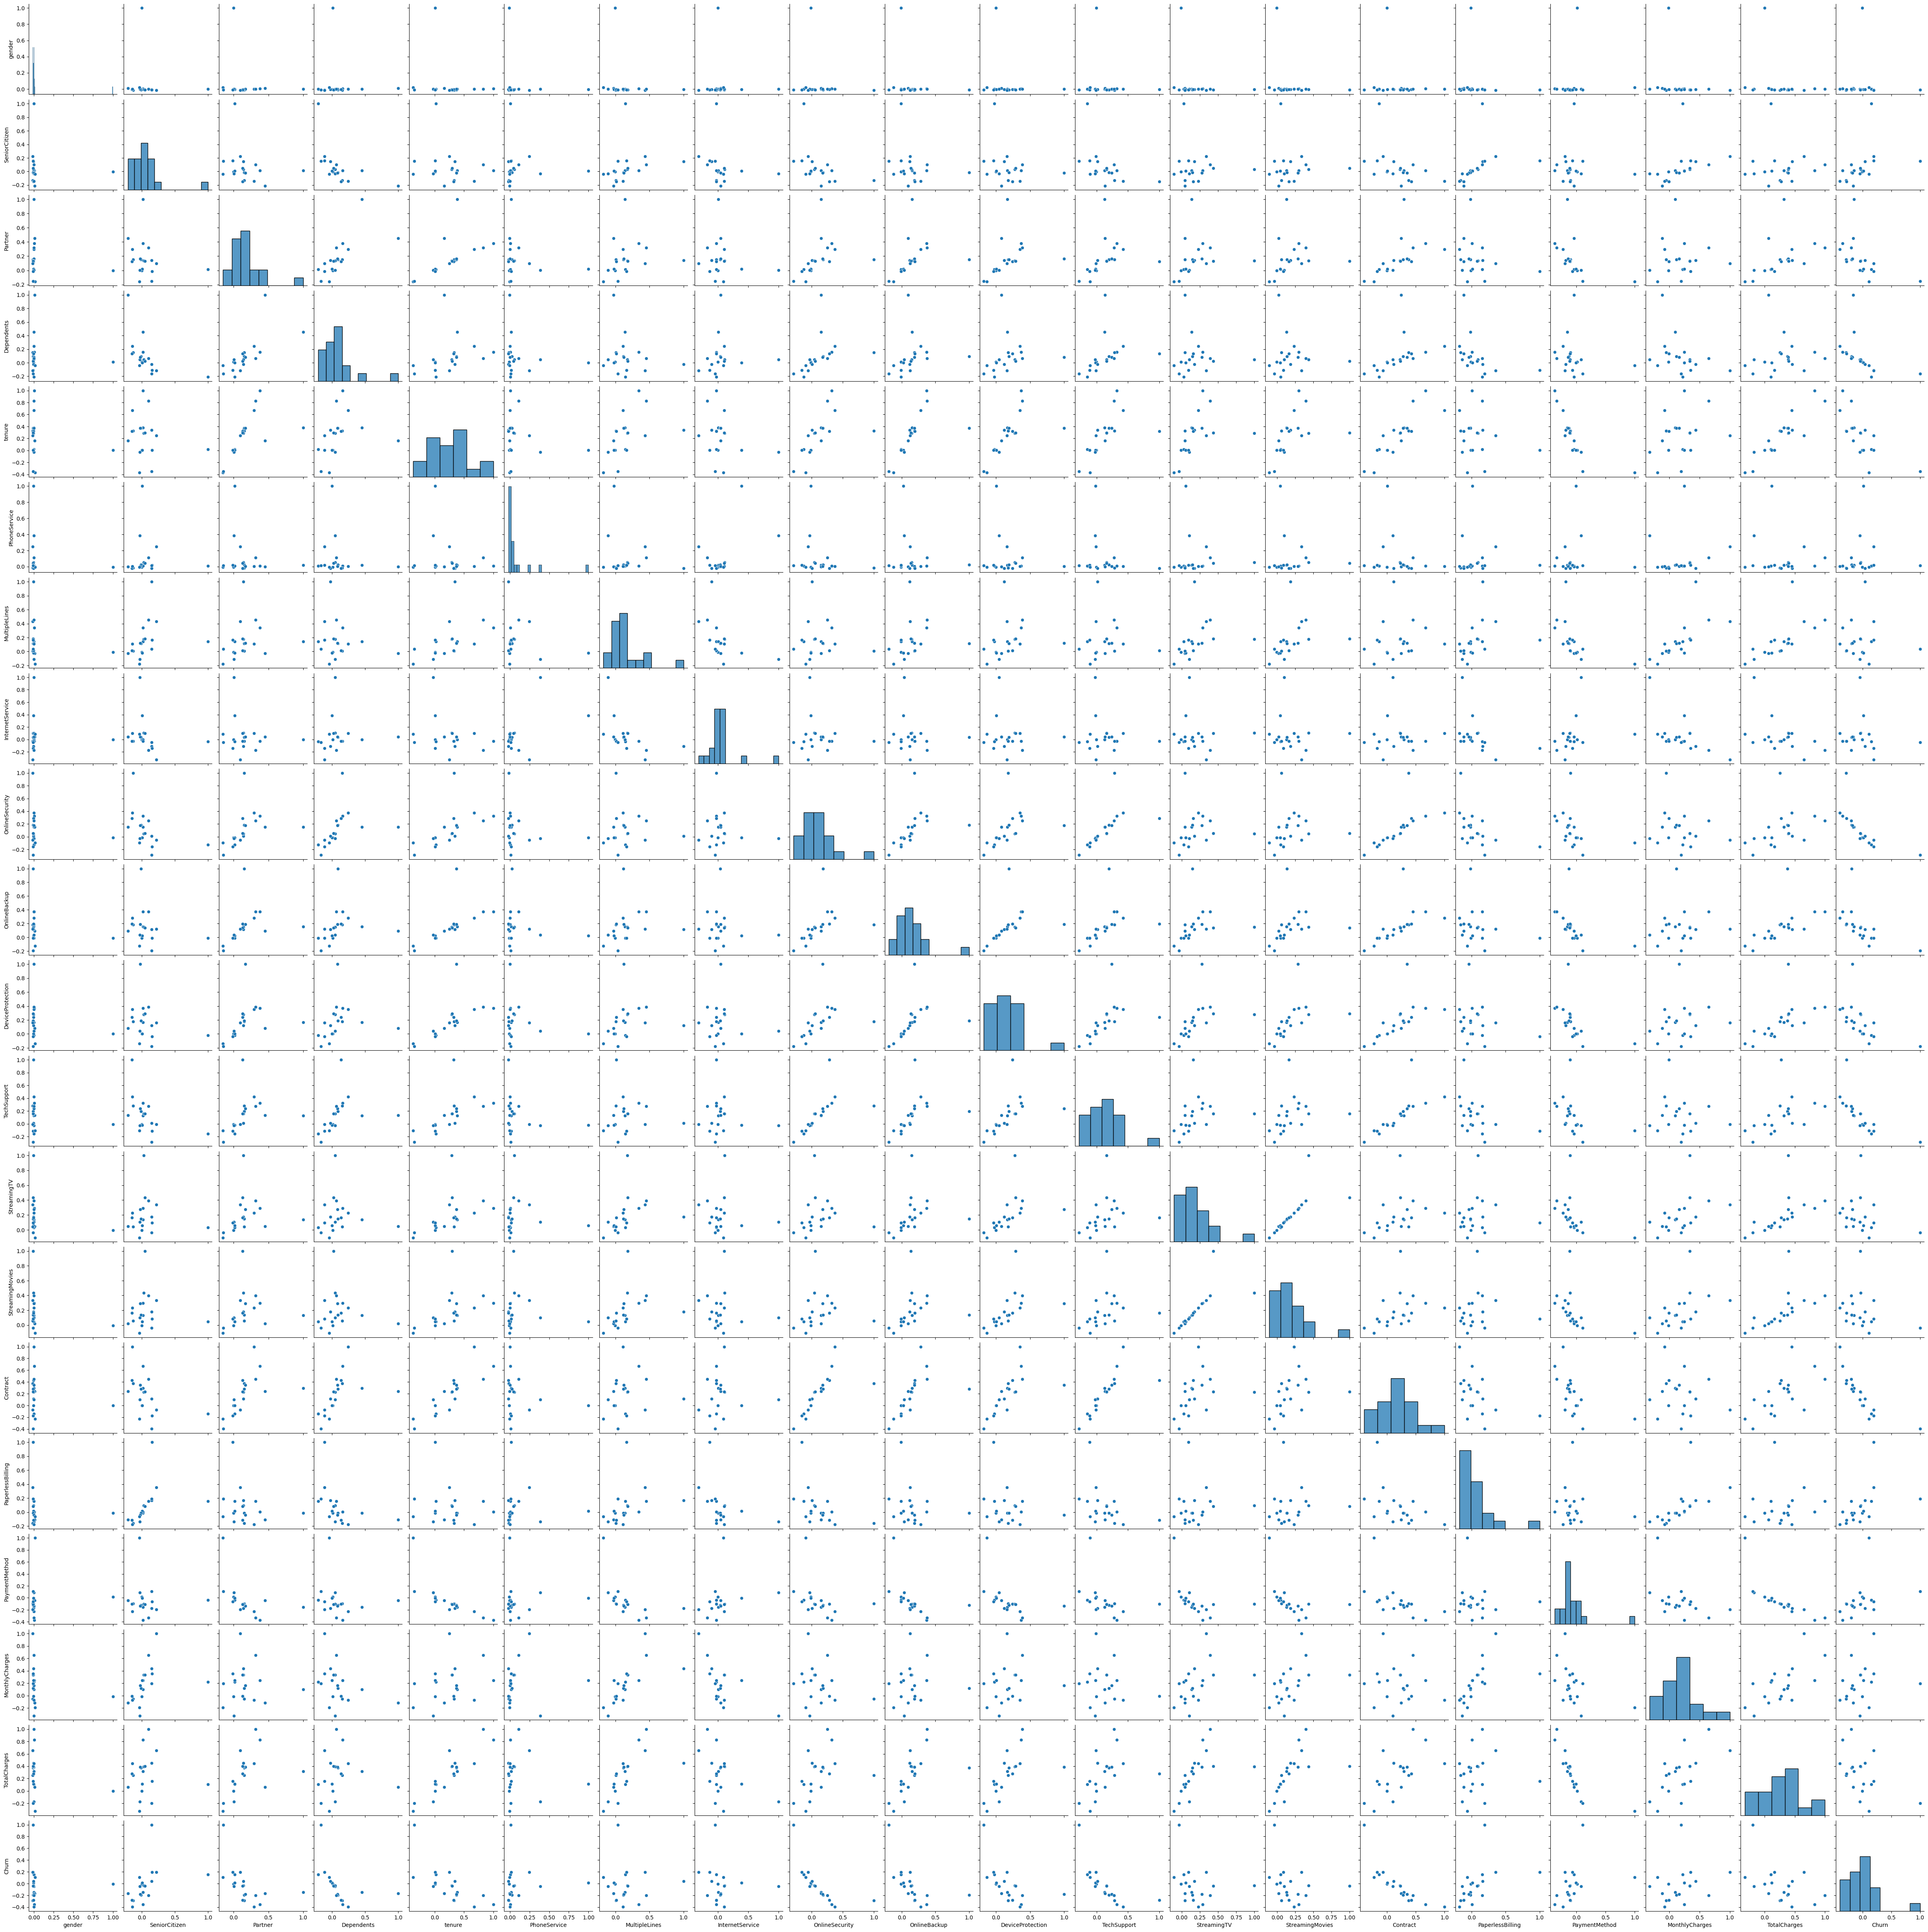

In [143]:
sns.pairplot(data_set.corr())

<Axes: xlabel='tenure', ylabel='MonthlyCharges'>

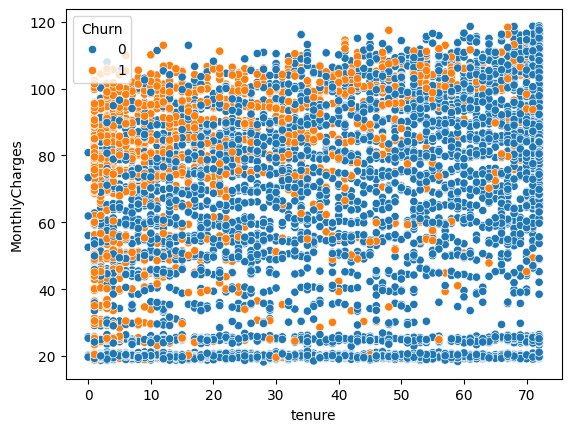

In [144]:
sns.scatterplot(data=data_set,x='tenure',y='MonthlyCharges',hue='Churn')

/tmp/ipykernel_3681/1639225169.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_set['tenure'])


<Axes: xlabel='tenure', ylabel='Density'>

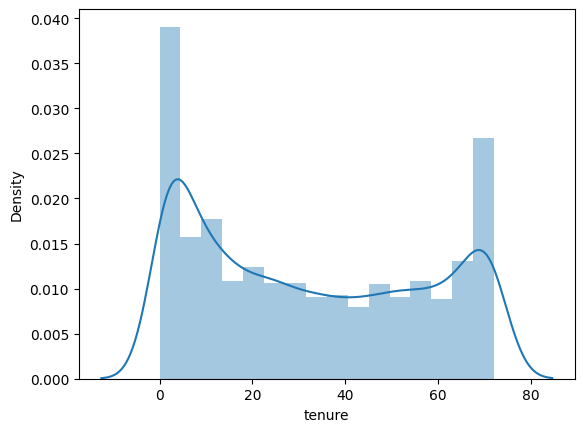

In [145]:
sns.distplot(data_set['tenure'])

<Axes: xlabel='Contract', ylabel='MonthlyCharges'>

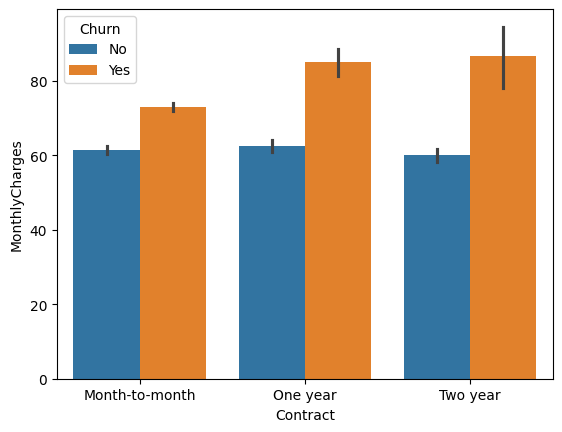

In [146]:
sns.barplot(data=df,x='Contract',y='MonthlyCharges',hue='Churn')

<Axes: xlabel='StreamingTV', ylabel='count'>

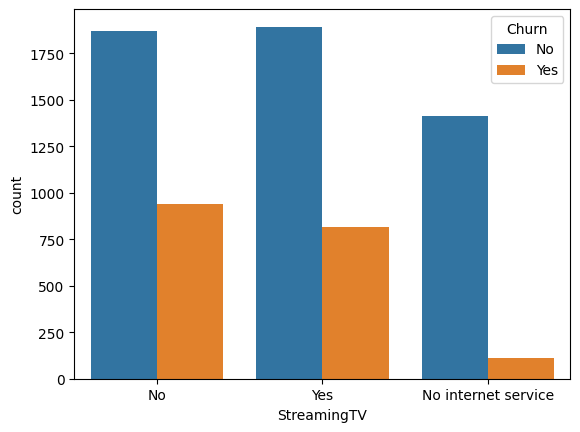

In [147]:
sns.countplot(data=df,x="StreamingTV",hue='Churn')

<Axes: xlabel='PaymentMethod', ylabel='count'>

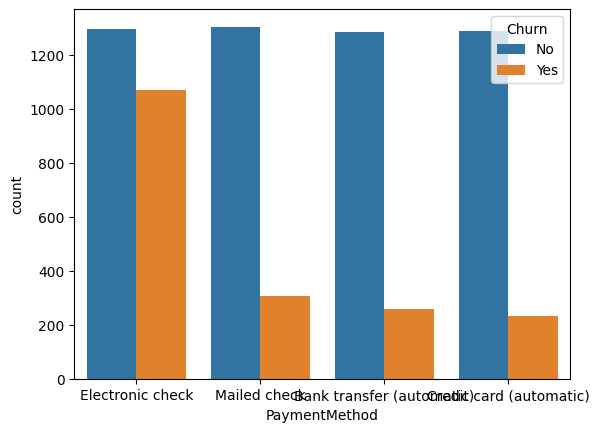

In [148]:
sns.countplot(data=df,x="PaymentMethod",hue='Churn')

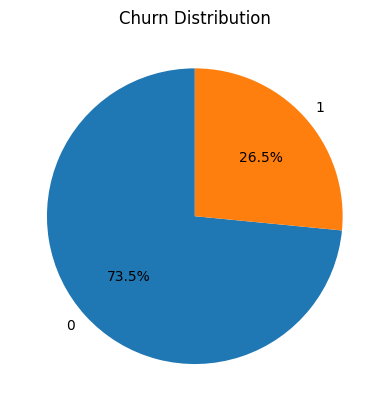

In [149]:
churn_counts = data_set['Churn'].value_counts()
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Churn Distribution')
plt.show()

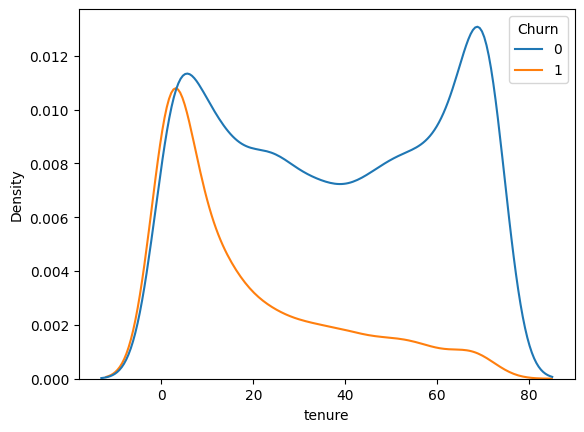

In [150]:
sns.kdeplot(data=data_set,x='tenure',hue='Churn')
plt.show()

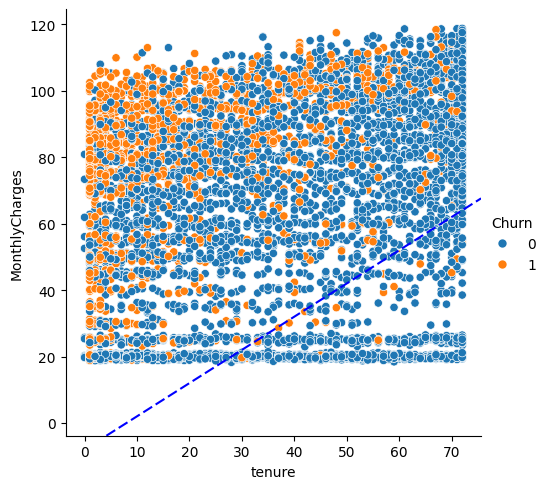

In [151]:
g=sns.relplot(data=data_set,x='tenure',y='MonthlyCharges',hue='Churn')
g.ax.axline(xy1=(10, 2), slope=1, color="b", dashes=(5, 2))


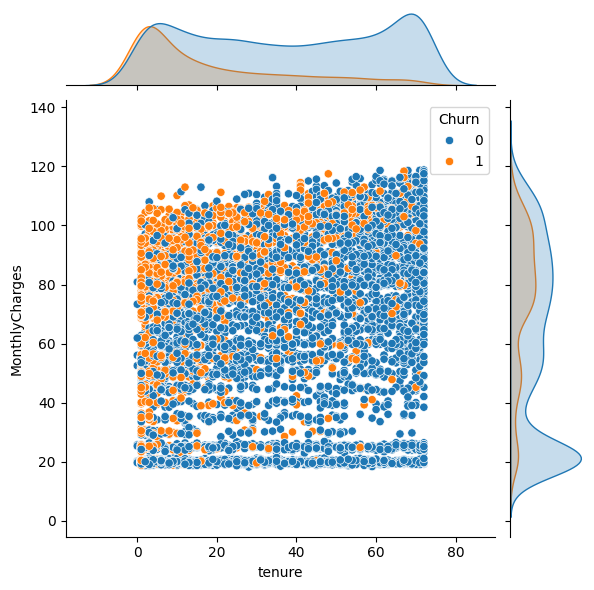

In [152]:
sns.jointplot(data=data_set,x='tenure',y='MonthlyCharges',hue='Churn')

In [153]:
from sklearn.model_selection import train_test_split
data_set

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50,0
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90,0
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45,0
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60,1


In [154]:
X=data_set.drop(columns=["Churn"],axis=1)
y=data_set["Churn"]

In [155]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)


In [156]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [157]:
X_test
print(X_train)

[[-1.02516569e+00 -4.37749204e-01 -9.69578591e-01 ...  1.33926673e+00
  -4.73723375e-04 -4.19924521e-01]
 [-1.02516569e+00 -4.37749204e-01 -9.69578591e-01 ... -1.47094882e+00
   1.07475386e+00  1.25601669e+00]
 [ 9.75452077e-01 -4.37749204e-01  1.03137591e+00 ...  4.02528212e-01
  -1.37649913e+00 -1.00028321e+00]
 ...
 [ 9.75452077e-01 -4.37749204e-01  1.03137591e+00 ...  4.02528212e-01
  -1.45294499e+00 -8.75404569e-01]
 [ 9.75452077e-01  2.28441306e+00 -9.69578591e-01 ...  4.02528212e-01
   1.14953785e+00 -4.80309046e-01]
 [ 9.75452077e-01 -4.37749204e-01 -9.69578591e-01 ... -5.34210304e-01
  -1.49781538e+00 -8.08568424e-01]]


In [158]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 19)
(1409, 19)
(5634,)
(1409,)


In [159]:
from sklearn.ensemble import RandomForestRegressor
randomfor=RandomForestRegressor()
randomfor.fit(X_train,y_train)
y_pred=randomfor.predict(X_test)

In [160]:
y_pred

array([0.75, 0.11, 0.02, ..., 0.03, 0.  , 0.41])

In [161]:
from sklearn.metrics import accuracy_score,precision_score,f1_score,classification_report,confusion_matrix

# Convert continuous predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred >= 0.5).astype(int)

accu_random=accuracy_score(y_test,y_pred_binary)
accu_random

0.7828246983676366

In [162]:
y_pred_binary

array([1, 0, 0, ..., 0, 0, 0])

In [163]:
# Import libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Assume features already extracted
# X = features
# y = labels

# Example (remove if you already have X and y)
# from sklearn.datasets import load_iris
# data = load_iris()
# X = data.data
# y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Dictionary of models
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(n_estimators=100),

    "Support Vector Machine": SVC(),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Naive Bayes": GaussianNB()
}

# Train and evaluate models
for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    print(name, "Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.815471965933286
Decision Tree Accuracy: 0.7182398864442867
Random Forest Accuracy: 0.7998580553584103
Support Vector Machine Accuracy: 0.7352732434350603
KNN Accuracy: 0.7778566359119943
Naive Bayes Accuracy: 0.7565649396735273


In [164]:
# Train and evaluate models
for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Accuracy
    prec = precision_score(y_test, y_pred)

    print(name, "precision score",prec)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression precision score 0.6782334384858044
Decision Tree precision score 0.4896373056994819
Random Forest precision score 0.6605839416058394
Support Vector Machine precision score 0.0
KNN precision score 0.6
Naive Bayes precision score 0.5274725274725275


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [165]:
from sklearn.linear_model import LogisticRegression
logregre=LogisticRegression()
logregre.fit(X_train,y_train)
y_pred=logregre.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [166]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.89      0.86      0.87      1081
           1       0.58      0.66      0.62       328

    accuracy                           0.81      1409
   macro avg       0.74      0.76      0.75      1409
weighted avg       0.82      0.81      0.81      1409



In [167]:
print(accuracy_score(y_pred,y_test))

0.8105039034776437


In [168]:
print(confusion_matrix(y_pred,y_test))

[[925 156]
 [111 217]]


In [169]:
import pickle

# save model
with open("logistic_model.pkl", "wb") as f:
    pickle.dump(model, f)

# save StandardScaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(sc, f)

print("Model and scaler saved successfully")

Model and scaler saved successfully


In [170]:
import os
print(os.listdir())

['.config', 'logistic_model.pkl', 'sample_data', '.ipynb_checkpoints', 'scaler.pkl']
